<a href="https://colab.research.google.com/github/furged/oceanEmbed-Prototype/blob/anushka%2Foceanembed-prototype/notebooks/oceanembed_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# clone the repo
!git clone -b anushka/oceanembed-prototype https://github.com/furged/oceanEmbed-Prototype.git
%cd /content/oceanEmbed-Prototype
!git status

Cloning into 'oceanEmbed-Prototype'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 3), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 14.36 KiB | 525.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/oceanEmbed-Prototype
On branch anushka/oceanembed-prototype
Your branch is up to date with 'origin/anushka/oceanembed-prototype'.

nothing to commit, working tree clean


In [2]:
!pip -q install copernicusmarine xarray netCDF4 zarr dask

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 10.4 MB/s eta 0:00:00


In [3]:
import torch
import xarray as xr
import numpy as np
import copernicusmarine

print("torch:", torch.__version__)
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "not available")

torch: 2.11.0+cu128
gpu: Tesla T4


In [5]:
catalogue = copernicusmarine.describe(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m"
)

for product in catalogue.products:
    print("product:", product)
    for dataset in product.datasets:
        print("dataset:", dataset.dataset_id)


Fetching catalogue 1: 100%|██████████| 2/2 [00:56<00:00, 28.28s/it]
                                                                
Fetching catalogue 1:  50%|█████     | 1/2 [00:01<00:01,  1.89s/it]

product: title='Global Ocean Physics Reanalysis' product_id='GLOBAL_MULTIYEAR_PHY_001_030' thumbnail_url='https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/GLOBAL_MULTIYEAR_PHY_001_030.jpg' description='The GLORYS12V1 product is the CMEMS global ocean eddy-resolving (1/12° horizontal resolution, 50 vertical levels) reanalysis covering the altimetry (1993 onward).\n\nIt is based largely on the current real-time global forecasting CMEMS system. The model component is the NEMO platform driven at surface by ECMWF ERA-Interim then ERA5 reanalyses for recent years. Observations are assimilated by means of a reduced-order Kalman filter. Along track altimeter data (Sea Level Anomaly), Satellite Sea Surface Temperature, Sea Ice Concentration and In situ Temperature and Salinity vertical Profiles are jointly assimilated. Moreover, a 3D-VAR scheme provides a correction for the slowly-evolving large-scale biases in temperature and salinity.\n\nThis product includes daily and monthl

In [7]:
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao", "so", "zos"],
    minimum_longitude=70,
    maximum_longitude=90,
    minimum_latitude=5,
    maximum_latitude=20,
    minimum_depth=0.49,
    maximum_depth=222.48,
    start_datetime="2020-01-01",
    end_datetime="2020-06-30",
    output_directory="/content/oceanEmbed-Prototype/data",
    output_filename="glorys_nio_small.nc"
)

INFO - 2026-09-04T07:00:10Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: ashakya12
Copernicus Marine password: ··········


INFO - 2026-09-04T07:00:36Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-04T07:00:36Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-04T07:00:36Z - Some of your subset selection [0.49, 222.48] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-09-04T07:28:25Z - Total size of the download: 1.20 GB.
INFO:copernicusmarine:Total size of the download: 1.20 GB.


ResponseSubset(file_path=PosixPath('/content/oceanEmbed-Prototype/data/glorys_nio_small.nc'), output_directory=PosixPath('/content/oceanEmbed-Prototype/data'), filename='glorys_nio_small.nc', file_size=1227.2282328244273, data_transfer_size=48214.64134351145, variables=['thetao', 'so', 'zos'], coordinates_extent=[GeographicalExtent(minimum=70.0, maximum=90.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.0, maximum=20.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2020-01-01T00:00:00+00:00', maximum='2020-06-30T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=222.47520446777344, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [9]:
import xarray as xr

ds = xr.open_dataset("/content/oceanEmbed-Prototype/data/glorys_nio_small.nc")

print(ds)
print("\nshape:")
for dim, size in ds.sizes.items():
    print(dim, size)

print("\nvariables:")
print(list(ds.data_vars))

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 182, depth: 27, latitude: 181, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2020-01-01 2020-01-02 ... 2020-06-30
  * depth      (depth) float32 108B 0.494 1.541 2.646 ... 155.9 186.1 222.5
  * latitude   (latitude) float32 724B 5.0 5.083 5.167 5.25 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 964B 70.0 70.08 70.17 ... 89.83 89.92 90.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 2GB ...
    so         (time, depth, latitude, longitude) float64 2GB ...
    zos        (time, latitude, longitude) float64 64MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
 

In [10]:
target_depths = [
    0.49, 1.54, 2.65, 5.08, 7.93,
    11.40, 15.81, 21.60, 29.44, 40.34,
    55.76, 77.85, 109.73, 155.85, 222.48
]

ds_small = ds.sel(depth=target_depths, method="nearest").astype("float32")

print(ds_small)
print("\nselected depths:")
print(ds_small.depth.values)

<xarray.Dataset> Size: 984MB
Dimensions:    (time: 182, depth: 15, latitude: 181, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2020-01-01 2020-01-02 ... 2020-06-30
  * depth      (depth) float32 60B 0.494 1.541 2.646 5.078 ... 109.7 155.9 222.5
  * latitude   (latitude) float32 724B 5.0 5.083 5.167 5.25 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 964B 70.0 70.08 70.17 ... 89.83 89.92 90.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 476MB 29.19 ... 13.29
    so         (time, depth, latitude, longitude) float32 476MB 34.62 ... 34.97
    zos        (time, latitude, longitude) float32 32MB 0.4883 0.4886 ... 0.7352
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    r

In [11]:
sst = ds_small.thetao.isel(depth=0)
sss = ds_small.so.isel(depth=0)
ssh = ds_small.zos

y = ds_small.thetao

print("sst:", sst.shape)
print("sss:", sss.shape)
print("ssh:", ssh.shape)
print("target:", y.shape)

sst: (182, 181, 241)
sss: (182, 181, 241)
ssh: (182, 181, 241)
target: (182, 15, 181, 241)


In [12]:
import numpy as np

print("sst nan:", np.isnan(sst.values).sum())
print("sss nan:", np.isnan(sss.values).sum())
print("ssh nan:", np.isnan(ssh.values).sum())
print("target nan:", np.isnan(y.values).sum())

sst nan: 2151422
sss nan: 2151422
ssh nan: 2151422
target nan: 36056202


In [13]:
ocean_mask = ~np.isnan(sst.isel(time=0).values)

print("ocean cells:", ocean_mask.sum())
print("land cells:", (~ocean_mask).sum())
print("total cells:", ocean_mask.size)

ocean cells: 31800
land cells: 11821
total cells: 43621


In [14]:
n = len(ds_small.time)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

print("total days:", n)
print("training days:", train_end)
print("validation days:", val_end - train_end)
print("test days:", n - val_end)

total days: 182
training days: 127
validation days: 27
test days: 28


In [15]:
X = np.stack([
    sst.values,
    sss.values,
    ssh.values
], axis=1)

Y = y.values

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

print("X train:", X_train.shape)
print("X val:", X_val.shape)
print("X test:", X_test.shape)

print("Y train:", Y_train.shape)
print("Y val:", Y_val.shape)
print("Y test:", Y_test.shape)

X train: (127, 3, 181, 241)
X val: (27, 3, 181, 241)
X test: (28, 3, 181, 241)
Y train: (127, 15, 181, 241)
Y val: (27, 15, 181, 241)
Y test: (28, 15, 181, 241)


In [16]:
x_mean = np.nanmean(X_train, axis=(0, 2, 3), keepdims=True)
x_std = np.nanstd(X_train, axis=(0, 2, 3), keepdims=True)

y_mean = np.nanmean(Y_train, axis=(0, 2, 3), keepdims=True)
y_std = np.nanstd(Y_train, axis=(0, 2, 3), keepdims=True)

X_train = (X_train - x_mean) / (x_std + 1e-6)
X_val = (X_val - x_mean) / (x_std + 1e-6)
X_test = (X_test - x_mean) / (x_std + 1e-6)

Y_train = (Y_train - y_mean) / (y_std + 1e-6)
Y_val = (Y_val - y_mean) / (y_std + 1e-6)
Y_test = (Y_test - y_mean) / (y_std + 1e-6)

print("normalization complete")
print("x mean:", x_mean.flatten())
print("x std:", x_std.flatten())

normalization complete
x mean: [28.81459   33.666096   0.5244875]
x std: [1.3671024  1.071572   0.08337434]


In [17]:
X_train = np.nan_to_num(X_train, nan=0.0)
X_val = np.nan_to_num(X_val, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)

Y_train = np.nan_to_num(Y_train, nan=0.0)
Y_val = np.nan_to_num(Y_val, nan=0.0)
Y_test = np.nan_to_num(Y_test, nan=0.0)

print("remaining NaNs:")
print("X train:", np.isnan(X_train).sum())
print("Y train:", np.isnan(Y_train).sum())

remaining NaNs:
X train: 0
Y train: 0


In [18]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, Y_train_t),
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, Y_val_t),
    batch_size=2,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_t, Y_test_t),
    batch_size=2,
    shuffle=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 64
val batches: 14
test batches: 14


In [19]:
import torch.nn as nn

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.weights = nn.Parameter(
            torch.randn(
                in_channels,
                out_channels,
                modes1,
                modes2,
                dtype=torch.cfloat
            ) * 0.02
        )

    def forward(self, x):
        batch_size = x.shape[0]

        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :self.modes1, :self.modes2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, :self.modes1, :self.modes2],
            self.weights
        )

        return torch.fft.irfft2(
            out_ft,
            s=(x.size(-2), x.size(-1))
        )


class FNO2d(nn.Module):
    def __init__(self, in_channels=3, out_channels=15):
        super().__init__()

        self.lift = nn.Conv2d(in_channels, 32, 1)

        self.spectral1 = SpectralConv2d(32, 32, 16, 16)
        self.spectral2 = SpectralConv2d(32, 32, 16, 16)
        self.spectral3 = SpectralConv2d(32, 32, 16, 16)

        self.conv1 = nn.Conv2d(32, 32, 1)
        self.conv2 = nn.Conv2d(32, 32, 1)
        self.conv3 = nn.Conv2d(32, 32, 1)

        self.activation = nn.GELU()

        self.project = nn.Sequential(
            nn.Conv2d(32, 64, 1),
            nn.GELU(),
            nn.Conv2d(64, out_channels, 1)
        )

    def forward(self, x):
        x = self.lift(x)

        x = self.activation(
            self.spectral1(x) + self.conv1(x)
        )

        x = self.activation(
            self.spectral2(x) + self.conv2(x)
        )

        x = self.activation(
            self.spectral3(x) + self.conv3(x)
        )

        return self.project(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FNO2d().to(device)

print("device:", device)
print("parameters:", sum(p.numel() for p in model.parameters()))

device: cuda
parameters: 792815


In [20]:
xb, yb = next(iter(train_loader))

xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    pred = model(xb)

print("input:", xb.shape)
print("target:", yb.shape)
print("prediction:", pred.shape)

input: torch.Size([2, 3, 181, 241])
target: torch.Size([2, 15, 181, 241])
prediction: torch.Size([2, 15, 181, 241])


In [21]:
import torch.optim as optim

mask = torch.tensor(ocean_mask, dtype=torch.float32, device=device)
mask = mask.unsqueeze(0).unsqueeze(0)

def masked_mse(pred, target):
    error = (pred - target) ** 2
    error = error * mask
    return error.sum() / mask.sum() / pred.shape[1]

optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("loss: masked mse")
print("optimizer: adam")
print("learning rate: 0.001")

loss: masked mse
optimizer: adam
learning rate: 0.001


In [22]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss = masked_mse(pred, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = masked_mse(pred, yb)

            val_loss += loss.item()

    train_mse = train_loss / len(train_loader)
    val_mse = val_loss / len(val_loader)

    train_rmse = train_mse ** 0.5
    val_rmse = val_mse ** 0.5

    print(
        f"epoch {epoch + 1}/{num_epochs} "
        f"train rmse: {train_rmse:.4f} "
        f"val rmse: {val_rmse:.4f}"
    )

epoch 1/10 train rmse: 1.0615 val rmse: 0.8286
epoch 2/10 train rmse: 0.5041 val rmse: 0.7409
epoch 3/10 train rmse: 0.4073 val rmse: 0.6973
epoch 4/10 train rmse: 0.3612 val rmse: 0.6641
epoch 5/10 train rmse: 0.3321 val rmse: 0.6407
epoch 6/10 train rmse: 0.3117 val rmse: 0.6350
epoch 7/10 train rmse: 0.3009 val rmse: 0.6385
epoch 8/10 train rmse: 0.2872 val rmse: 0.6391
epoch 9/10 train rmse: 0.2782 val rmse: 0.6186
epoch 10/10 train rmse: 0.2659 val rmse: 0.6246


In [23]:
model.eval()

test_squared_error = 0.0
test_count = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)

        error = (pred - yb) ** 2
        error = error * mask

        test_squared_error += error.sum().item()
        test_count += mask.sum().item() * pred.shape[1]

test_rmse_normalized = (test_squared_error / test_count) ** 0.5

y_scale = float(np.mean(y_std))

test_rmse_celsius = test_rmse_normalized * y_scale

print(f"test rmse normalized: {test_rmse_normalized:.4f}")
print(f"test rmse celsius: {test_rmse_celsius:.4f} °C")

test rmse normalized: 0.8350
test rmse celsius: 1.1452 °C


In [24]:
model = FNO2d().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
best_val_rmse = float("inf")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss = masked_mse(pred, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = masked_mse(pred, yb)

            val_loss += loss.item()

    train_rmse = (train_loss / len(train_loader)) ** 0.5
    val_rmse = (val_loss / len(val_loader)) ** 0.5

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), "best_fno.pt")
        marker = " * best"

    else:
        marker = ""

    print(
        f"epoch {epoch + 1}/{num_epochs} "
        f"train rmse: {train_rmse:.4f} "
        f"val rmse: {val_rmse:.4f}{marker}"
    )

print(f"\nbest validation rmse: {best_val_rmse:.4f}")

epoch 1/15 train rmse: 1.1070 val rmse: 0.8939 * best
epoch 2/15 train rmse: 0.5071 val rmse: 0.7182 * best
epoch 3/15 train rmse: 0.4037 val rmse: 0.6806 * best
epoch 4/15 train rmse: 0.3595 val rmse: 0.6572 * best
epoch 5/15 train rmse: 0.3297 val rmse: 0.6350 * best
epoch 6/15 train rmse: 0.3078 val rmse: 0.6269 * best
epoch 7/15 train rmse: 0.2934 val rmse: 0.6349
epoch 8/15 train rmse: 0.2839 val rmse: 0.6329
epoch 9/15 train rmse: 0.2722 val rmse: 0.6093 * best
epoch 10/15 train rmse: 0.2637 val rmse: 0.6048 * best
epoch 11/15 train rmse: 0.2566 val rmse: 0.6039 * best
epoch 12/15 train rmse: 0.2514 val rmse: 0.6119
epoch 13/15 train rmse: 0.2484 val rmse: 0.6028 * best
epoch 14/15 train rmse: 0.2401 val rmse: 0.5942 * best
epoch 15/15 train rmse: 0.2462 val rmse: 0.5952

best validation rmse: 0.5942


In [25]:
model.load_state_dict(torch.load("best_fno.pt", weights_only=True))
model.eval()

test_squared_error = 0.0
test_count = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)

        error = (pred - yb) ** 2
        error = error * mask

        test_squared_error += error.sum().item()
        test_count += mask.sum().item() * pred.shape[1]

test_rmse_normalized = (test_squared_error / test_count) ** 0.5
test_rmse_celsius = test_rmse_normalized * float(np.mean(y_std))

print(f"best validation rmse: {best_val_rmse:.4f}")
print(f"test rmse normalized: {test_rmse_normalized:.4f}")
print(f"test rmse celsius: {test_rmse_celsius:.4f} °C")

best validation rmse: 0.5942
test rmse normalized: 0.7676
test rmse celsius: 1.0527 °C


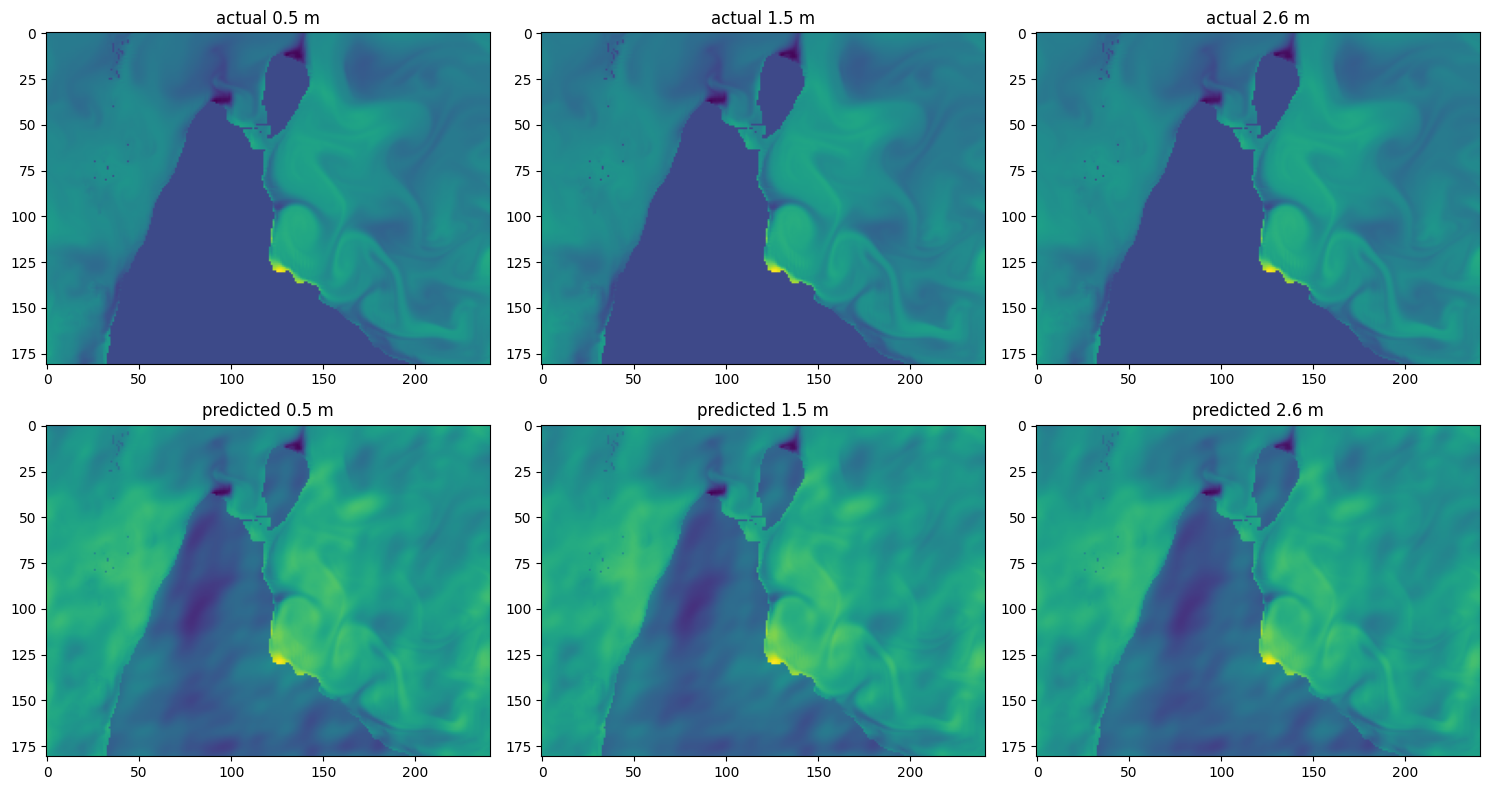

In [26]:
import matplotlib.pyplot as plt

xb, yb = next(iter(test_loader))

xb = xb.to(device)

with torch.no_grad():
    pred = model(xb)

pred = pred[0].cpu().numpy()
actual = yb[0].numpy()

depths = ds_small.depth.values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, depth in enumerate([0, 4, 8]):
    axes[0, i].imshow(actual[i], aspect="auto")
    axes[0, i].set_title(f"actual {depths[i]:.1f} m")

    axes[1, i].imshow(pred[i], aspect="auto")
    axes[1, i].set_title(f"predicted {depths[i]:.1f} m")

plt.tight_layout()
plt.show()

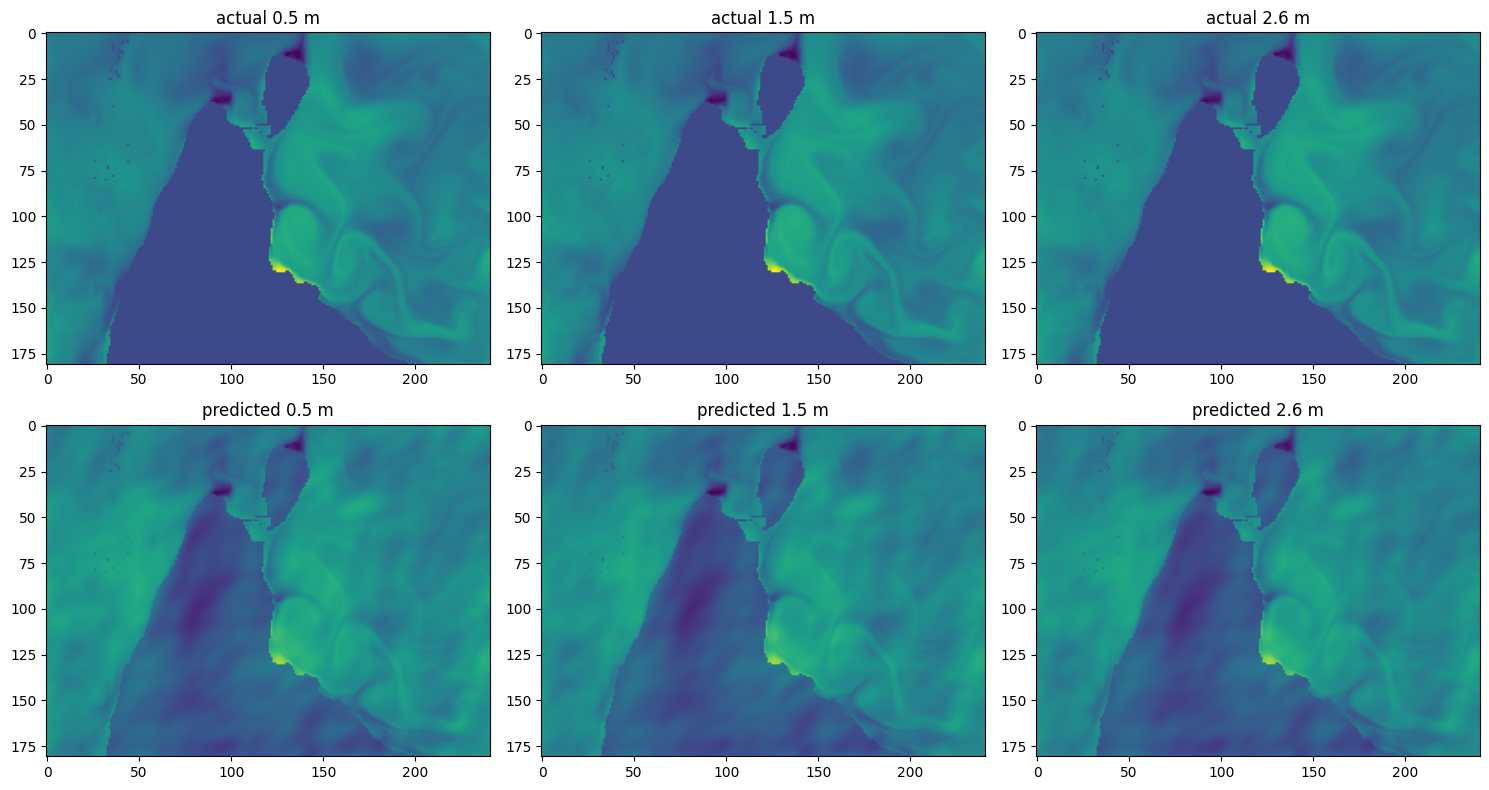

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    vmin = np.nanmin(actual[i])
    vmax = np.nanmax(actual[i])

    axes[0, i].imshow(actual[i], aspect="auto", vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f"actual {depths[i]:.1f} m")

    axes[1, i].imshow(pred[i], aspect="auto", vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f"predicted {depths[i]:.1f} m")

plt.tight_layout()
plt.show()

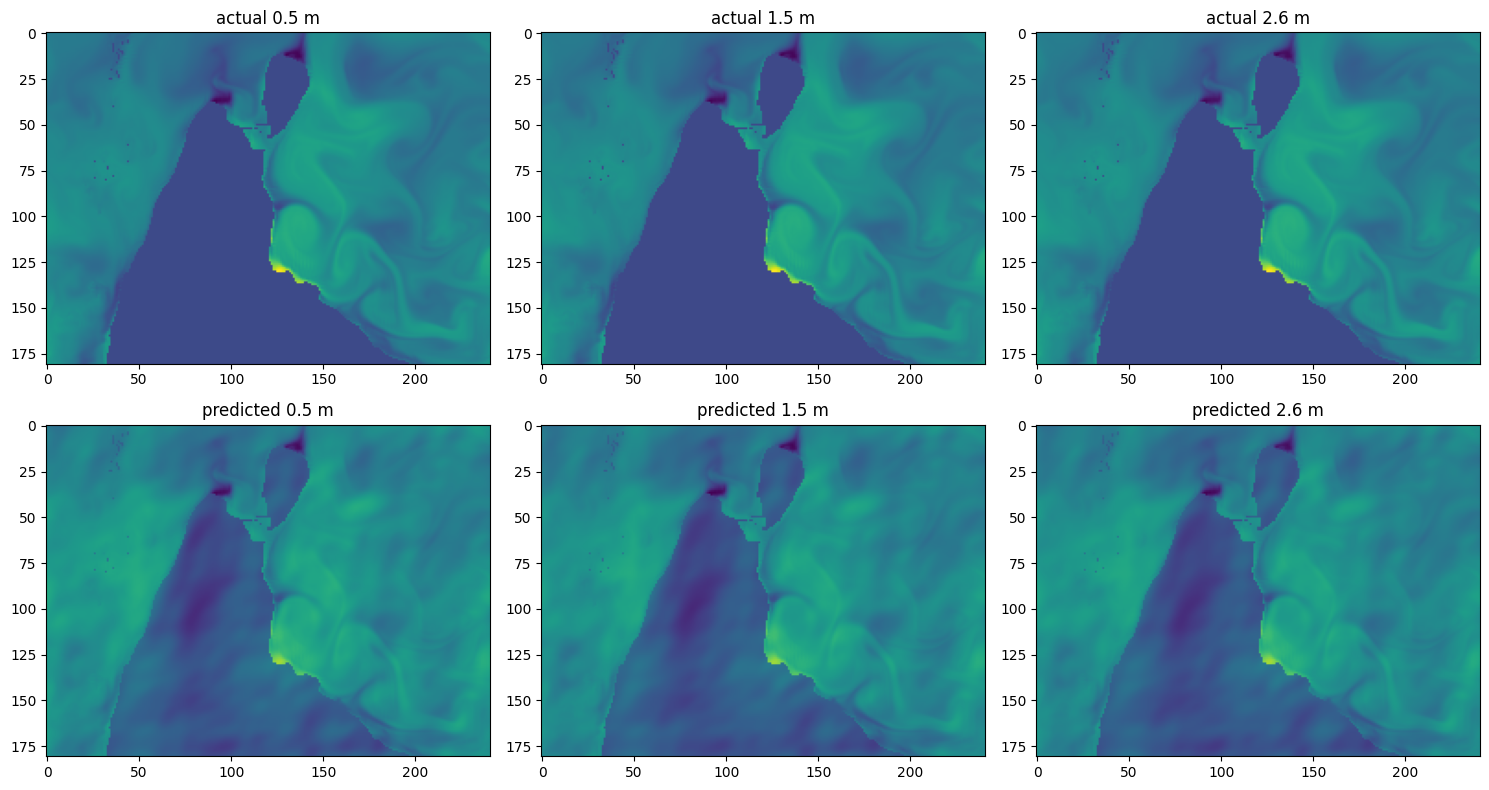

In [29]:
y_mean_3d = y_mean.reshape(15, 1, 1)
y_std_3d = y_std.reshape(15, 1, 1)

pred_c = pred * y_std_3d + y_mean_3d
actual_c = actual * y_std_3d + y_mean_3d

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    vmin = np.nanmin(actual_c[i])
    vmax = np.nanmax(actual_c[i])

    axes[0, i].imshow(actual_c[i], aspect="auto", vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f"actual {depths[i]:.1f} m")

    axes[1, i].imshow(pred_c[i], aspect="auto", vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f"predicted {depths[i]:.1f} m")

plt.tight_layout()
plt.show()

In [30]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        pred_batch = model(xb).cpu().numpy()

        all_preds.append(pred_batch)
        all_targets.append(yb.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

rmse_by_depth = np.sqrt(
    np.mean(
        (all_preds - all_targets) ** 2,
        axis=(0, 2, 3)
    )
) * y_std.reshape(-1)

for depth, rmse in zip(depths, rmse_by_depth):
    print(f"{depth:7.2f} m  →  {rmse:.4f} °C")

   0.49 m  →  0.3672 °C
   1.54 m  →  0.3214 °C
   2.65 m  →  0.2878 °C
   5.08 m  →  0.2761 °C
   7.93 m  →  0.2618 °C
  11.40 m  →  0.2751 °C
  15.81 m  →  0.3032 °C
  21.60 m  →  0.3632 °C
  29.44 m  →  0.5023 °C
  40.34 m  →  0.7392 °C
  55.76 m  →  0.9915 °C
  77.85 m  →  1.4412 °C
 109.73 m  →  1.3531 °C
 155.85 m  →  0.8996 °C
 222.48 m  →  0.5552 °C


In [31]:
mae_by_depth = np.mean(
    np.abs(all_preds - all_targets),
    axis=(0, 2, 3)
) * y_std.reshape(-1)

for depth, mae in zip(depths, mae_by_depth):
    print(f"{depth:7.2f} m  →  {mae:.4f} °C")

   0.49 m  →  0.3116 °C
   1.54 m  →  0.2656 °C
   2.65 m  →  0.2345 °C
   5.08 m  →  0.2229 °C
   7.93 m  →  0.2043 °C
  11.40 m  →  0.2114 °C
  15.81 m  →  0.2330 °C
  21.60 m  →  0.2797 °C
  29.44 m  →  0.3831 °C
  40.34 m  →  0.5556 °C
  55.76 m  →  0.6707 °C
  77.85 m  →  1.0641 °C
 109.73 m  →  1.0476 °C
 155.85 m  →  0.6796 °C
 222.48 m  →  0.4103 °C
